<a href="https://colab.research.google.com/github/xiaann622/Analystlab/blob/Week-7/weather_etl_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 Project: Weather ETL Pipeline — African Capital Cities

**Goal:** Build an ETL (Extract, Transform, Load) pipeline using the OpenWeather API for all **54 African capital cities**.

Pipeline stages:
1. **Extract** — pull live current-weather data from the OpenWeather API for every capital
2. **Transform** — clean it into a tidy Pandas DataFrame
3. **Load** — save it as CSV and SQLite
4. **Analyze** — compare cities and find patterns

> **Why current weather, not historical?** OpenWeather's free plan only gives current conditions and a 5-day forecast — past dates require their paid History API. To stay strictly on OpenWeather's free tier, this pipeline instead scales *out* (many cities) rather than back in time.

> Run each cell from top to bottom. This notebook is written to be presented in a screen-recorded demo.

## Step 0: Install & import libraries

In [1]:
!pip install requests pandas -q

import os
import sqlite3
import time
from datetime import datetime, timezone

import pandas as pd
import requests

## Step 1: Configuration
Your OpenWeather API key and the full list of African capital cities.

**Security tip for your video/GitHub repo:** don't leave a real API key visible in a public notebook. In Colab you can instead store it in `Secrets` (key icon on the left sidebar) and load it with `from google.colab import userdata; API_KEY = userdata.get('OPENWEATHER_API_KEY')`. For this walkthrough we set it directly so it's easy to explain.

In [2]:
API_KEY = "237d8a4bb2cc446b90675166828660e9"

# All 54 African capital cities as "City,CountryCode" pairs
CITIES = [
    "Algiers,DZ", "Luanda,AO", "Porto-Novo,BJ", "Gaborone,BW", "Ouagadougou,BF",
    "Gitega,BI", "Praia,CV", "Yaounde,CM", "Bangui,CF", "N'Djamena,TD",
    "Moroni,KM", "Brazzaville,CG", "Kinshasa,CD", "Djibouti,DJ", "Cairo,EG",
    "Malabo,GQ", "Asmara,ER", "Mbabane,SZ", "Addis Ababa,ET", "Libreville,GA",
    "Banjul,GM", "Accra,GH", "Conakry,GN", "Bissau,GW", "Yamoussoukro,CI",
    "Nairobi,KE", "Maseru,LS", "Monrovia,LR", "Tripoli,LY", "Antananarivo,MG",
    "Lilongwe,MW", "Bamako,ML", "Nouakchott,MR", "Port Louis,MU", "Rabat,MA",
    "Maputo,MZ", "Windhoek,NA", "Niamey,NE", "Abuja,NG", "Kigali,RW",
    "Sao Tome,ST", "Dakar,SN", "Victoria,SC", "Freetown,SL", "Mogadishu,SO",
    "Pretoria,ZA", "Juba,SS", "Khartoum,SD", "Dodoma,TZ", "Lome,TG",
    "Tunis,TN", "Kampala,UG", "Lusaka,ZM", "Harare,ZW",
]

print(f"Total cities: {len(CITIES)}")

BASE_URL = "https://api.openweathermap.org/data/2.5/weather"

Total cities: 54


## Task 1: EXTRACT
Call the OpenWeather **Current Weather** endpoint once per city (54 calls total — well within the free plan's 60-calls/minute, 1,000,000-calls/month limit) and collect the raw JSON responses. Cities that fail to resolve are skipped, not fatal.

In [9]:
def extract_weather_data(cities, api_key):
    raw_records = []
    for i, city in enumerate(cities, start=1):
        params = {"q": city, "appid": api_key, "units": "metric"}
        response = requests.get(BASE_URL, params=params, timeout=10)
        if response.status_code == 200:
            raw_records.append(response.json())
            print(f"[{i}/{len(cities)}] {city:<20} : OK")
        else:
            print(f"[{i}/{len(cities)}] {city:<20} -> FAILED ({response.status_code})")
        time.sleep(0.2)  # be polite to the rate limit
    print(f"\nExtracted raw data for {len(raw_records)} of {len(cities)} cities.")
    return raw_records

raw_data = extract_weather_data(CITIES, API_KEY)
raw_data[0]

[1/54] Algiers,DZ           : OK
[2/54] Luanda,AO            : OK
[3/54] Porto-Novo,BJ        : OK
[4/54] Gaborone,BW          : OK
[5/54] Ouagadougou,BF       : OK
[6/54] Gitega,BI            : OK
[7/54] Praia,CV             : OK
[8/54] Yaounde,CM           : OK
[9/54] Bangui,CF            : OK
[10/54] N'Djamena,TD         : OK
[11/54] Moroni,KM            : OK
[12/54] Brazzaville,CG       : OK
[13/54] Kinshasa,CD          : OK
[14/54] Djibouti,DJ          : OK
[15/54] Cairo,EG             : OK
[16/54] Malabo,GQ            : OK
[17/54] Asmara,ER            : OK
[18/54] Mbabane,SZ           : OK
[19/54] Addis Ababa,ET       : OK
[20/54] Libreville,GA        : OK
[21/54] Banjul,GM            : OK
[22/54] Accra,GH             : OK
[23/54] Conakry,GN           : OK
[24/54] Bissau,GW            : OK
[25/54] Yamoussoukro,CI      : OK
[26/54] Nairobi,KE           : OK
[27/54] Maseru,LS            : OK
[28/54] Monrovia,LR          : OK
[29/54] Tripoli,LY           : OK
[30/54] Antananarivo,MG

{'coord': {'lon': 3.042, 'lat': 36.7525},
 'weather': [{'id': 801,
   'main': 'Clouds',
   'description': 'few clouds',
   'icon': '02n'}],
 'base': 'stations',
 'main': {'temp': 24.9,
  'feels_like': 25.48,
  'temp_min': 24.9,
  'temp_max': 24.9,
  'pressure': 1018,
  'humidity': 78,
  'sea_level': 1018,
  'grnd_level': 1012},
 'visibility': 10000,
 'wind': {'speed': 0.51, 'deg': 0},
 'clouds': {'all': 18},
 'dt': 1788035515,
 'sys': {'type': 1,
  'id': 1060,
  'country': 'DZ',
  'sunrise': 1787980587,
  'sunset': 1788027700},
 'timezone': 3600,
 'id': 2507480,
 'name': 'Algiers',
 'cod': 200}

## Task 2: TRANSFORM
Pull out just the fields we need, rename them clearly, and fix data types (numbers as numbers, timestamps as real datetimes).

In [10]:
def transform_weather_data(raw_records):
    rows = []
    for record in raw_records:
        rows.append({
            "city": record.get("name"),
            "country": record.get("sys", {}).get("country"),
            "temperature_celsius": record.get("main", {}).get("temp"),
            "feels_like_celsius": record.get("main", {}).get("feels_like"),
            "humidity_percent": record.get("main", {}).get("humidity"),
            "weather_condition": record.get("weather", [{}])[0].get("main"),
            "weather_description": record.get("weather", [{}])[0].get("description"),
            "wind_speed_mps": record.get("wind", {}).get("speed"),
            "recorded_at_utc": datetime.fromtimestamp(record.get("dt", 0), tz=timezone.utc),
        })

    df = pd.DataFrame(rows)

    numeric_cols = ["temperature_celsius", "feels_like_celsius", "humidity_percent", "wind_speed_mps"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["weather_condition"] = df["weather_condition"].str.title()
    df["weather_description"] = df["weather_description"].str.title()
    df = df.dropna(subset=["city"]).reset_index(drop=True)
    df = df.sort_values("city").reset_index(drop=True)
    return df

clean_df = transform_weather_data(raw_data)
clean_df

,city,country,temperature_celsius,feels_like_celsius,humidity_percent,weather_condition,weather_description,wind_speed_mps,recorded_at_utc
0,Abuja,NG,23.72,24.60,94,Rain,Light Rain,1.10,2026-08-29 20:32:47+00:00
1,Accra,GH,25.23,25.98,83,Rain,Light Rain,5.66,2026-08-29 20:32:41+00:00
2,Addis Ababa,ET,14.49,14.29,88,Clouds,Broken Clouds,3.09,2026-08-29 20:32:40+00:00
3,Algiers,DZ,24.90,25.48,78,Clouds,Few Clouds,0.51,2026-08-29 20:31:55+00:00
4,Antananarivo,MG,11.98,11.37,82,Clouds,Overcast Clouds,4.12,2026-08-29 20:32:44+00:00
5,Asmara,ER,19.26,18.89,63,Clear,Clear Sky,1.02,2026-08-29 20:32:00+00:00
6,Bamako,ML,30.23,35.60,70,Clouds,Broken Clouds,1.54,2026-08-29 20:32:45+00:00
7,Bangui,CF,25.10,26.12,94,Clouds,Broken Clouds,1.03,2026-08-29 20:32:37+00:00
8,Bissau,GW,27.06,30.80,89,Rain,Moderate Rain,1.03,2026-08-29 20:32:42+00:00
9,Brazzaville,CG,23.20,23.74,83,Clouds,Few Clouds,1.03,2026-08-29 20:32:38+00:00


## Task 3: LOAD
Save the clean dataset to a CSV file and a SQLite database so it can be reused for future analysis.

In [11]:
os.makedirs("data", exist_ok=True)

csv_path = "data/weather_data.csv"
db_path = "data/weather_data.db"

clean_df.to_csv(csv_path, index=False)
print(f"Saved CSV to {csv_path}")

conn = sqlite3.connect(db_path)
clean_df.to_sql("weather_data", conn, if_exists="replace", index=False)
conn.close()
print(f"Saved SQLite DB to {db_path}")

Saved CSV to data/weather_data.csv
Saved SQLite DB to data/weather_data.db


## Task 4: BASIC ANALYSIS
Compare temperature, humidity, and conditions across all African capitals.

In [12]:
hottest = clean_df.loc[clean_df["temperature_celsius"].idxmax()]
coolest = clean_df.loc[clean_df["temperature_celsius"].idxmin()]
most_humid = clean_df.loc[clean_df["humidity_percent"].idxmax()]
windiest = clean_df.loc[clean_df["wind_speed_mps"].idxmax()]
condition_counts = clean_df["weather_condition"].value_counts()

print("===== WEATHER ANALYSIS SUMMARY: AFRICAN CAPITAL CITIES =====")
print(f"Cities analyzed: {len(clean_df)}")
print(f"Hottest city:    {hottest['city']} ({hottest['temperature_celsius']}°C)")
print(f"Coolest city:    {coolest['city']} ({coolest['temperature_celsius']}°C)")
print(f"Most humid city: {most_humid['city']} ({most_humid['humidity_percent']}% humidity)")
print(f"Windiest city:   {windiest['city']} ({windiest['wind_speed_mps']} m/s)")
print(f"\nAverage temperature across all cities: {clean_df['temperature_celsius'].mean():.1f}°C")
print(f"Average humidity across all cities:    {clean_df['humidity_percent'].mean():.1f}%")
print("\nMost common weather conditions right now:")
for condition, count in condition_counts.head(5).items():
    print(f"  - {condition}: {count} cities")

===== WEATHER ANALYSIS SUMMARY: AFRICAN CAPITAL CITIES =====
Cities analyzed: 54
Hottest city:    Khartoum (37.26°C)
Coolest city:    Mbabane (11.01°C)
Most humid city: Yaoundé (99% humidity)
Windiest city:   Victoria (8.75 m/s)

Average temperature across all cities: 23.4°C
Average humidity across all cities:    71.1%

Most common weather conditions right now:
  - Clouds: 35 cities
  - Clear: 11 cities
  - Rain: 8 cities



Top 10 hottest capitals right now — nice to show in the demo video.

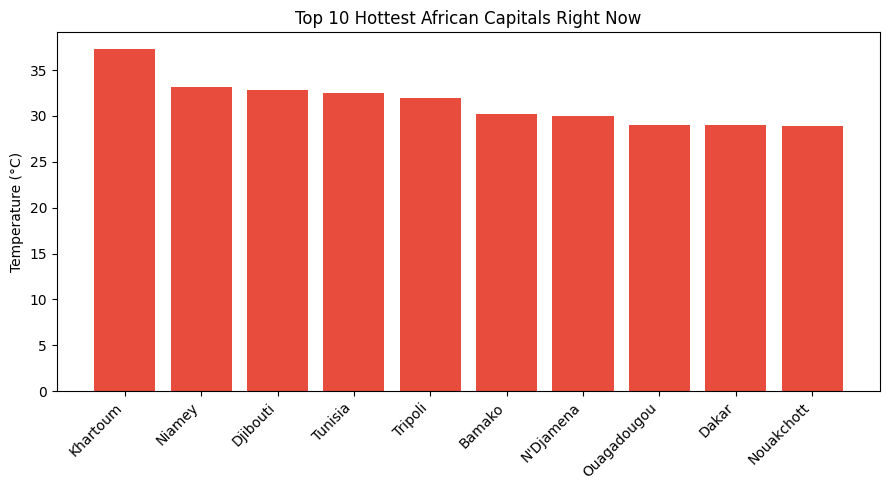

In [13]:
import matplotlib.pyplot as plt

top10 = clean_df.sort_values("temperature_celsius", ascending=False).head(10)

plt.figure(figsize=(9, 5))
plt.bar(top10["city"], top10["temperature_celsius"], color="#e74c3c")
plt.title("Top 10 Hottest African Capitals Right Now")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("data/top10_hottest.png")
plt.show()

In [14]:
try:
    from google.colab import files
    files.download(csv_path)
    files.download(db_path)
except ImportError:
    print("Not running in Colab — files are already saved locally in the 'data' folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>